In [2]:
from plots_utils import *
import pandas as pd

# healthy: PCA_H3BERTA_HEALTHY_REPERTOIRE_WITHCDRH3DUPLICATES_700011206 PCA embeddings.csv

Min di v_identity: 69.512
Max di v_identity: 100.000
Min di j_identity: 80.000
Max di j_identity: 100.000


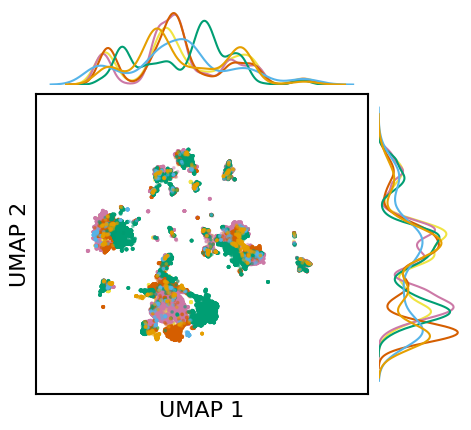

<Figure size 300x100 with 0 Axes>

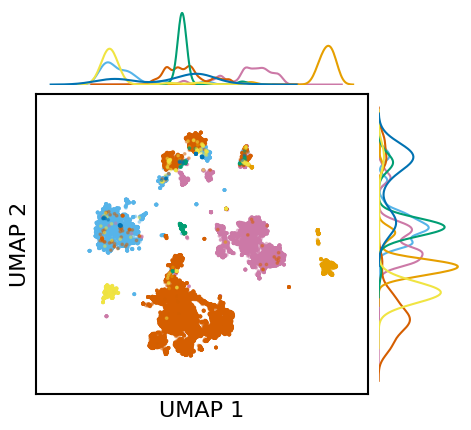

<Figure size 300x100 with 0 Axes>

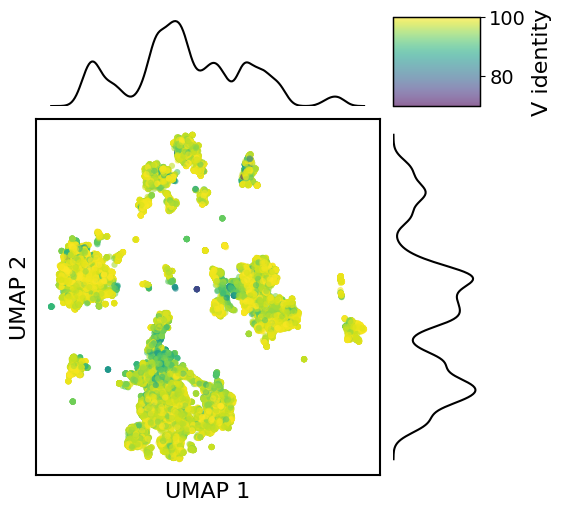

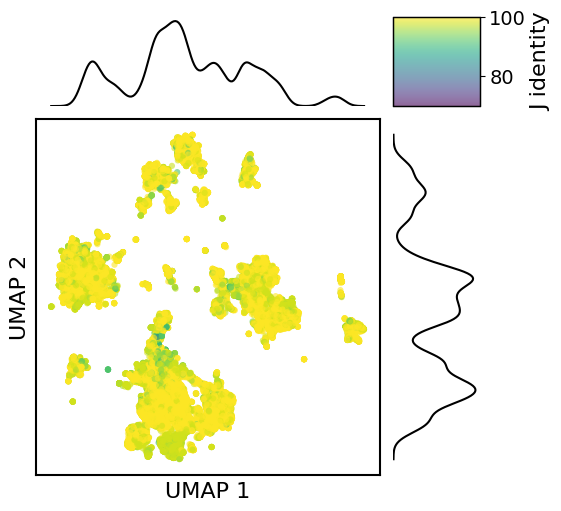

In [3]:
df = pd.read_csv("./out_healthy/PCA_Ab-RoBERTa_HEALTHY_REPERTOIRE_WITHCDRH3DUPLICATES_700011206 PCA embeddings.csv")
for col in ['v_family', 'j_family', 'd_family']:
    df[col] = df[col].astype(str).str.split('/', n=1).str[0]
    df[col] = df[col].astype(str).str.split('-', n=1).str[0]
    
gene_col = 'v_identity'
min_val = df[gene_col].min()
max_val = df[gene_col].max()
print(f"Min di {gene_col}: {min_val:.3f}")
print(f"Max di {gene_col}: {max_val:.3f}")

gene_col = 'j_identity'
min_val = df[gene_col].min()
max_val = df[gene_col].max()
print(f"Min di {gene_col}: {min_val:.3f}")
print(f"Max di {gene_col}: {max_val:.3f}")

plot_umap_single_gene_INSCAPE(df, gene_col= 'j_family', title= 'D Gene', file_suffix="./img/PAPER_ABROBERTA_HEALTHY_700011206")
plot_umap_single_gene_INSCAPE(df, gene_col= 'v_family', title= 'D Gene', file_suffix="./img/PAPER_ABROBERTA_HEALTHY_700011206")
plot_umap_single_gene_numeric_INSCAPE(df, gene_col= 'v_identity', title= 'V identity', file_suffix="./img/PAPER_ABROBERTA_HEALTHY_700011206", value_range=(70, 100))
plot_umap_single_gene_numeric_INSCAPE(df, gene_col= 'j_identity', title= 'J identity', file_suffix="./img/PAPER_ABROBERTA_HEALTHY_700011206", value_range=(70, 100))

# bnabs: ./out_bnabs/PCA_H3BERTA_BNABS_REPERTOIRE_WITHCDRH3DUPLICATES_702010293 PCA embeddings.csv

In [6]:
# df = pd.read_csv("./out_bnabs/PCA_Ab-RoBERTa_BNABS_REPERTOIRE_WITHCDRH3DUPLICATES_702010293 PCA embeddings.csv")
# for col in ['v_family', 'j_family', 'd_family']:
#     df[col] = df[col].astype(str).str.split('/', n=1).str[0]
#     df[col] = df[col].astype(str).str.split('-', n=1).str[0]

# gene_col = 'v_identity'
# min_val = df[gene_col].min()
# max_val = df[gene_col].max()
# print(f"Min di {gene_col}: {min_val:.3f}")
# print(f"Max di {gene_col}: {max_val:.3f}")

# gene_col = 'j_identity'
# min_val = df[gene_col].min()
# max_val = df[gene_col].max()
# print(f"Min di {gene_col}: {min_val:.3f}")
# print(f"Max di {gene_col}: {max_val:.3f}")

# plot_umap_single_gene_INSCAPE(df, gene_col= 'j_family', title= 'D Gene', file_suffix="./img/PAPER_ABROBERTA_BNABS_702010293")
# plot_umap_single_gene_INSCAPE(df, gene_col= 'v_family', title= 'D Gene', file_suffix="./img/PAPER_ABROBERTA_BNABS_702010293")
# plot_umap_single_gene_numeric_INSCAPE(df, gene_col= 'v_identity', title= 'V identity', file_suffix="./img/PAPER_ABROBERTA_BNABS_702010293", value_range=(80, 100))
# plot_umap_single_gene_numeric_INSCAPE(df, gene_col= 'j_identity', title= 'J identity', file_suffix="./img/PAPER_ABROBERTA_BNABS_702010293", value_range=(80, 100))


# therapeutical antibodies

FROM https://academic.oup.com/bioinformatics/article/37/22/4041/6295884?login=true#405570562

2.7 Anti-drug antibody response levels of therapeutics

Anti-drug antibody (ADA) responses of patients were obtained for 217 therapeutics from clinical papers using an identical approach to that described in Clavero-Alvarez et al. (2018). When multiple ADA levels are reported for the same therapeutic, the mean between the minimal and maximal reported value is used. We then obtained the sequences of 10 additional therapeutics, for which we had ADA response data but which were not included in Thera-SAbDab, from Clavero-Alvarez et al. (2018). The complete list of therapeutics together with observed immunogenicity levels can be found in the Supplementary Material.

In [7]:
import pandas as pd

# 1) Read the Excel file, skip the first 3 rows, and use the 4th row as the header
df = pd.read_excel("../Thera-SAbDab_btab434_supplementary_data/Therapeutic_Sequences.xlsx", skiprows=3)
df.columns = df.columns.map(str)
# 2) Verify that the “Name” column exists
assert "Name" in df.columns, "Column 'Name' not found in the sheet"

# 3) Define the list of CDRH3 segment columns in the desired order
cols_to_join = [str(i) for i in range(1, 111)] + [
    "111A","111B","111C","111D","111E","111F",
    "112G","112F","112E","112D","112C","112B","112A",
    "112"
] + [str(i) for i in range(113, 129)]

# 4) Build a new column “cdrh3” by concatenating the segment columns for each row:
#    - Fill NaN with empty string to avoid literal "nan"
#    - Cast all values to string
#    - Join them together in the specified order
df["sequence"] = (
    df[cols_to_join]
      .fillna("")              # replace missing values with ""
      .astype(str)             # convert all entries to string
      .agg("".join, axis=1)    # concatenate horizontally per row
      .replace("-","")
)
# Remove all hyphens from the 'cdrh3' column
df["sequence"] = df["sequence"].str.replace("-", "", regex=False)

mapping = {
    "u":    "Human",
    "zu":   "Humanized",
    "xizu": "Chimeric/Humanized",
    "xi":   "Chimeric",
    "o":    "Mouse"
}

df["Origin"] = df["Origin"].replace(mapping)

df = df[df['Origin']!='Chimeric/Humanized']
# 5) Extract only the “Name” and newly created “cdrh3” columns
sequences = df[["Name", "sequence",'Origin']]

###################################################################################################################
# 1) Read the Excel file, skip the first 3 rows, and use the 4th row as the header
df = pd.read_excel("../Thera-SAbDab_btab434_supplementary_data/Therapeutic_ADA.xlsx", skiprows=2)
df.columns = df.columns.map(str)

# 2) Verif that the “Name” column exists
assert "Name" in df.columns, "Column 'Name' not found in the sheet"

# 3) Define the list of CDRH3 segment columns in the desired order
cols_to_join = [
    "Name","Immunogenicity"
]

# 5) Extract only the “Name” and newly created “cdrh3” columns
ada = df[cols_to_join]

# 6) Preview or save the result
#print(ada.head())
#print(len(ada))

# --- Approach 2: pandas.Series.map (adds it in-place)
sequences = sequences.merge(
    ada[["Name", "Immunogenicity"]],  # only keep Name + the column you need
    on="Name",
    how="left"               # use 'left' so all df1 rows stay, missing matches become NaN
)
# crea una Serie contenente solo i valori non-NaN di 'my_col'
sequences = sequences.dropna(subset=['Immunogenicity'])

sequences.to_csv("Thera-SAbDab-ADA_fullsequence.csv",header=True,index=False)
sequences

,Name,sequence,Origin,Immunogenicity
0,Adalimumab,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,Human,14.000000
1,Afutuzumab,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,Humanized,6.642066
2,Alemtuzumab,QVQLQESGPGLVRPSQTLSLTCTVSGFTFTDFYMNWVRQPPGRGLE...,Humanized,5.100000
3,Alirocumab,EVQLVESGGGLVQPGGSLRLSCAASGFTFNNYAMNWVRQAPGKGLD...,Human,3.900000
4,Atezolizumab,EVQLVESGGGLVQPGGSLRLSCAASGFTFSDSWIHWVRQAPGKGLE...,Humanized,28.850000
...,...,...,...,...
348,Utomilumab,EVQLVQSGAEVKKPGESLRISCKGSGYSFSTYWISWVRQMPGKGLE...,Human,40.735000
351,Varlilumab,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYDMHWVRQAPGKGLE...,Human,0.000000
352,Veltuzumab,QVQLQQSGAEVKKPGSSVKVSCKASGYTFTSYNMHWVKQAPGQGLE...,Humanized,19.500000
356,Xentuzumab,QVELVESGGGLVQPGGSLRLSCAASGFTFTSYWMSWVRQAPGKGLE...,Humanized,2.300000


In [8]:
import pandas as pd
df = sequences.copy()
# Supponiamo che il tuo DataFrame si chiami df
# 1) Quante sequenze duplicate ci sono?
n_dup = df['sequence'].duplicated().sum()
print(f"Numero di righe che ripetono sequence: {n_dup}")

# 2) Quante sequenze uniche vs totali?
tot = len(df)
unique = df['sequence'].nunique()
print(f"Totale righe: {tot}, sequenze uniche: {unique}")

# 3) Visualizza tutte le righe che hanno sequence duplicata
df_dup = df[df['sequence'].duplicated(keep=False)]
print(df_dup)

# 4) Se vuoi solo i valori di sequence che compaiono più di una volta:
counts = df['sequence'].value_counts()
duplicated_seqs = counts[counts > 1].index.tolist()
print("Sequenze ripetute (>1 occorrenza):", duplicated_seqs)

# 5) Per vedere quante volte ciascuna di queste compare:
print(counts[counts > 1])


Numero di righe che ripetono sequence: 5
Totale righe: 199, sequenze uniche: 194
              Name                                           sequence  \
1       Afutuzumab  QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...   
62    Obinutuzumab  QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...   
138     Obexelimab  EVQLVESGGGLVKPGGSLKLSCAASGYTFTSYVMHWVRQAPGKGLE...   
158    Tafasitamab  EVQLVESGGGLVKPGGSLKLSCAASGYTFTSYVMHWVRQAPGKGLE...   
164    Ticilimumab  QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...   
167   Tremelimumab  QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...   
204     Coltuximab  QVQLVQPGAEVVKPGASVKLSCKTSGYTFTSNWMHWVKQAPGQGLE...   
243  Gatipotuzumab  EVQLVESGGGLVQPGGSMRLSCVASGFPFSNYWMNWVRQAPGKGLE...   
270  Loncastuximab  QVQLVQPGAEVVKPGASVKLSCKTSGYTFTSNWMHWVKQAPGQGLE...   
298       PankoMab  EVQLVESGGGLVQPGGSMRLSCVASGFPFSNYWMNWVRQAPGKGLE...   

        Origin  Immunogenicity  
1    Humanized        6.642066  
62   Humanized        6.000000  
138   Chimeric  

In [10]:
!mkdir out_ada

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Running model: Ab-RoBERTaADA
La cartella 'img' esiste già.
             Name                                           sequence  \
0      Adalimumab  EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...   
1     Alemtuzumab  QVQLQESGPGLVRPSQTLSLTCTVSGFTFTDFYMNWVRQPPGRGLE...   
2      Alirocumab  EVQLVESGGGLVQPGGSLRLSCAASGFTFNNYAMNWVRQAPGKGLD...   
3    Atezolizumab  EVQLVESGGGLVQPGGSLRLSCAASGFTFSDSWIHWVRQAPGKGLE...   
4        Avelumab  EVQLLESGGGLVQPGGSLRLSCAASGFTFSSYIMMWVRQAPGKGLE...   
..            ...                                                ...   
184    Utomilumab  EVQLVQSGAEVKKPGESLRISCKGSGYSFSTYWISWVRQMPGKGLE...   
185    Varlilumab  QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYDMHWVRQAPGKGLE...   
186    Veltuzumab  QVQLQQSGAEVKKPGSSVKVSCKASGYTFTSYNMHWVKQAPGQGLE...   
187    Xentuzumab  QVELVESGGGLVQPGGSLRLSCAASGFTFTSYWMSWVRQAPGKGLE...   
188   Zalutumumab  QVQLVESGGGVVQPGRSLRLSCAASGFTFSTYGMHWVRQAPGKGLE...   

        Origin  Immunogenicity  
0        Human          14.000  
1    Human

/home/rodelc/anaconda3/envs/aa_ss_tokenizer_2.0/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP coordinates saved to ./out_ada//UMAP_Ab-RoBERTaADA PCA embeddings.csv
IMG saved to img/UMAP_Ab-RoBERTaADA PCA embeddings.png


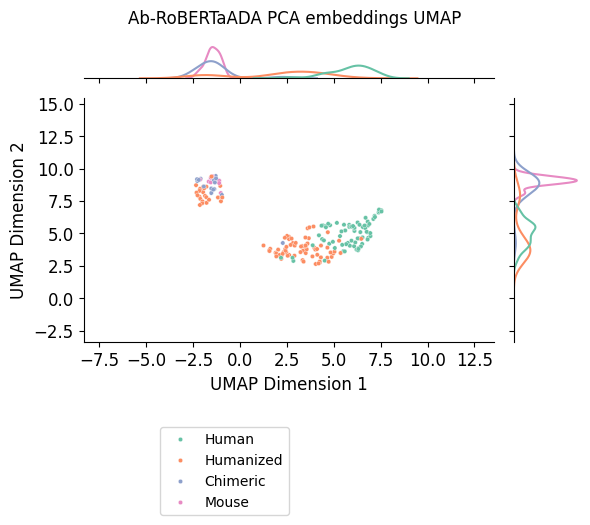

Computing PCA coordinates...
PCA coordinates saved to ./out_ada//PCA_Ab-RoBERTaADA PCA embeddings.csv


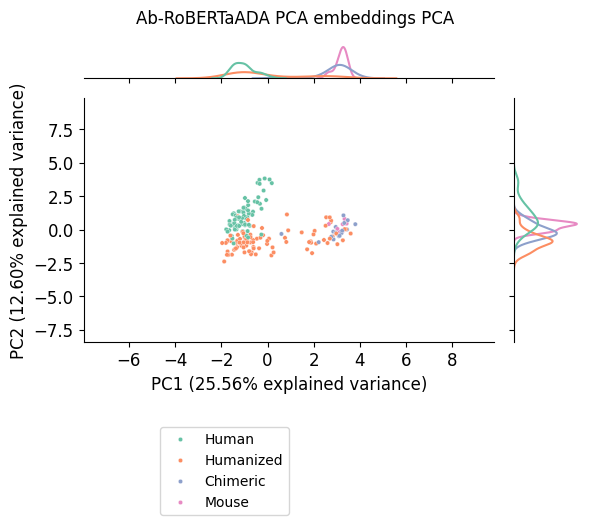

IMG saved to img/PCA_Ab-RoBERTaADA PCA embeddings.png


In [11]:
import os
from evaluate_mlm import main
import pandas as pd
from plots_utils import *

MODEL_PATH = "mogam-ai/Ab-RoBERTa"
#Percorso alla cartella dei file .txt
TXT_DIR = './Thera-SAbDab-ADA_fullsequence.csv'

# Colonne da assegnare manualmente ai file .txt


# Output directory
REDUCTION_OUTPUT_PATH = './out_ada/'

filepath = TXT_DIR
filename ="ADA"

# Legge il file come CSV senza intestazione, ma con separatore ','
df = pd.read_csv(filepath, header=0)
df = (
df.groupby('sequence', as_index=False)                # raggruppa per sequenza
.filter(lambda g: len(g.drop_duplicates()) == 1)    # scarta i gruppi "misti"
.drop_duplicates(subset='sequence')                 # rimuove l'unico duplicato rimasto
)


# Ora puoi passare il dataframe direttamente, oppure salvarlo in memoria come CSV-like string
# oppure modificare la funzione `main()` per accettare anche DataFrame in input
# Qui lo salviamo temporaneamente in memoria come oggetto CSV per compatibilità
tmp_csv_path = '/tmp/tmp_data.csv'
df.to_csv(tmp_csv_path, index=False)

model_name = 'Ab-RoBERTa' + filename.replace('.csv', '').upper()
embedding_file = f"./{model_name}_embeddings.pkl"
plot_title = model_name + ' PCA embeddings'
hue_class = 'Origin'

print(f"Running model: {model_name}")

main(model_name, MODEL_PATH, tmp_csv_path, embedding_file, plot_title, hue_class,
    REDUCTION_OUTPUT_PATH, umap=True, pca=True)



In [12]:


def plot_umap_single_gene_INSCAPE_biggerpoints_REVIEW(df, gene_col, title, file_suffix="output_umap"):
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    import matplotlib.gridspec as gridspec

    # Pulizia della colonna del gene
    df[gene_col] = df[gene_col].astype(str).str.split('-', n=1).str[0]

    # Layout con marginali
    fig = plt.figure(figsize=(5.5, 5))
    gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                        wspace=0.05, hspace=0.05)

    ax_main = fig.add_subplot(gs[1, 0])
    ax_marg_x = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_marg_y = fig.add_subplot(gs[1, 1], sharey=ax_main)

    handles = []
    labels = []

    for gene_val in df[gene_col].dropna().unique():
        sub_df = df[df[gene_col] == gene_val]
        style = custom_palette.get(gene_val, {'color': 'grey', 'size': 400, 'marker': 'o'})
        
        # Main scatter
        sc = ax_main.scatter(sub_df['umap1'], sub_df['umap2'],
                             c=[style['color']] * len(sub_df),
                             s=15, marker=style['marker'],
                             alpha=1.0, label=gene_val)
        handles.append(sc)
        labels.append(gene_val)

        # KDE marginali
        sns.kdeplot(sub_df['umap1'], ax=ax_marg_x, color=style['color'],
                    fill=False, linewidth=1.5, common_norm=False)
        sns.kdeplot(sub_df['umap2'], ax=ax_marg_y, color=style['color'],
                    fill=False, linewidth=1.5, common_norm=False, vertical=True)

    # Main plot settings
    ax_main.set_xticks([])
    ax_main.set_yticks([])
    ax_main.set_xlabel("UMAP 1", fontsize=16)
    ax_main.set_ylabel("UMAP 2", fontsize=16)

    ax_marg_x.axis('off')
    ax_marg_y.axis('off')

    # Bordi più spessi
    for ax in [ax_main, ax_marg_x, ax_marg_y]:
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

    # Salva la figura senza legenda
    plt.tight_layout()
    plt.savefig(f"{file_suffix}_umap_{gene_col}_NO_LEGEND.png", dpi=300, bbox_inches='tight')

    # Crea figura separata solo per la legenda
    fig_legend = plt.figure(figsize=(3, 1))  # Adatta le dimensioni come necessario
    legend = fig_legend.legend(handles, labels, title=title,
                               loc='center', fontsize=12, title_fontsize=14,
                               frameon=False, markerscale=5, ncol=2,
                               columnspacing=0.0, handletextpad=0.4, borderpad=0.0)
    fig_legend.canvas.draw()
    fig_legend.savefig(f"{file_suffix}_umap_{gene_col}_LEGEND.svg", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    plt.close(fig_legend)

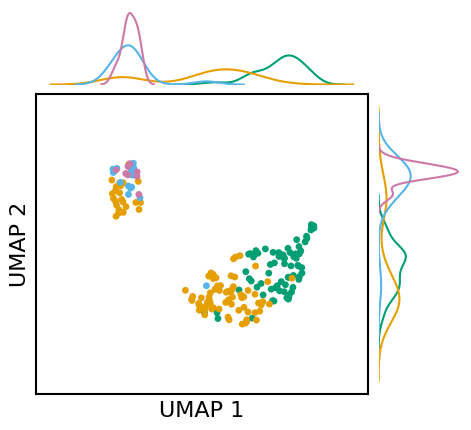

<Figure size 300x100 with 0 Axes>

In [14]:
from plots_utils import *
df = pd.read_csv("./out_ada/UMAP_Ab-RoBERTaADA PCA embeddings.csv")
#plot_umap_single_gene_numeric_INSCAPE_cmaporizzontale(df, gene_col= 'Immunogenicity', title= 'ADA', file_suffix="./img/PAPER_ADA", value_range=(0, 100))
plot_umap_single_gene_INSCAPE_biggerpoints_REVIEW(df, gene_col= 'Origin', title= 'Origin', file_suffix="./img/REVIEW_PAPER_ADA_Ab-RoBERTa")